In [ ]:
# TAREA 5 - REDES NEURONALES CONVUNCIONALES
'''
Reliza una aplicación de redes neuronales convolucionales para clasificar, segmentar o detectar objetos en imágenes.
Se toma una imagen con varias frutas para ver su comportamiento
'''

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input,
    decode_predictions
)

In [2]:
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


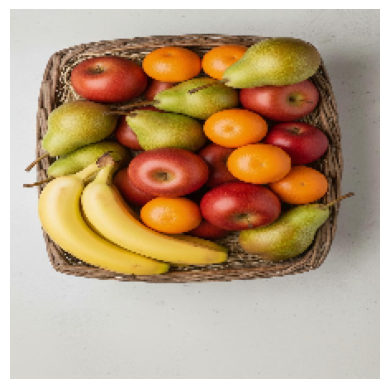

In [3]:
# Se lee la imagen
img_path = "fruits.jpg"

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

In [6]:
# y se entrena el modelo
pred = model.predict(x)

resultado = decode_predictions(pred, top=5)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
for _, clase, prob in resultado:
    print(f"{clase}: {prob*100:.2f}%")

banana: 62.04%
pineapple: 14.04%
fig: 4.61%
orange: 4.48%
tray: 3.72%


In [ ]:
'''
claramente se identifican resultados extraños porque para empezar no hay ninguna piña
sin embargo es lo que el modelo intenta clasificar con base en lo observado.

'''

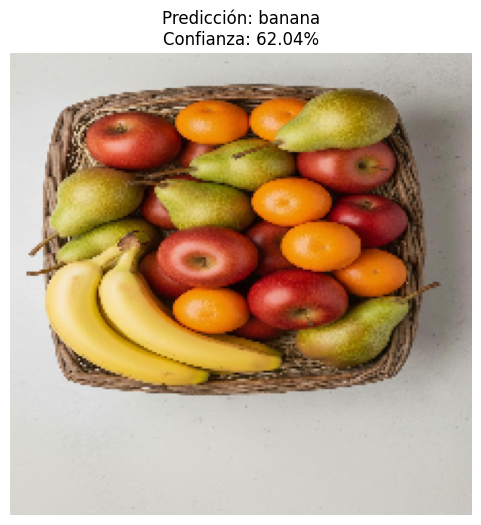

In [8]:
mejor = resultado[0]

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Predicción: {mejor[1]}\n"
    f"Confianza: {mejor[2]*100:.2f}%"
)

plt.show()

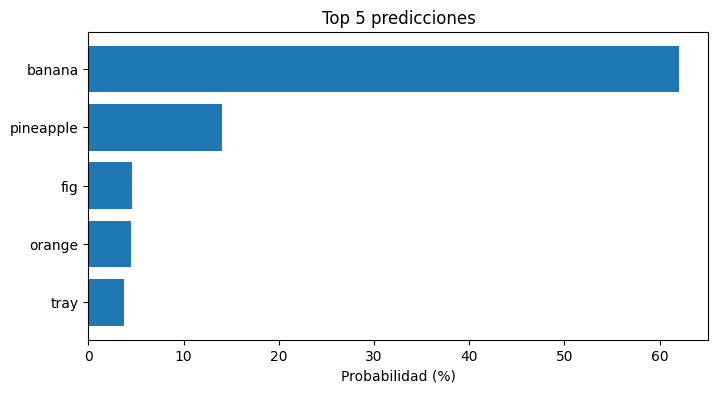

In [9]:
clases = [r[1] for r in resultado]
prob = [r[2]*100 for r in resultado]

plt.figure(figsize=(8,4))
plt.barh(clases, prob)
plt.xlabel("Probabilidad (%)")
plt.title("Top 5 predicciones")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
'''
se hace la prueba a continuación con una imagen que tenga menos elemenos,
es decir una sola fruta
y ver si con esto trata de hacer mejores aproximaciones
'''

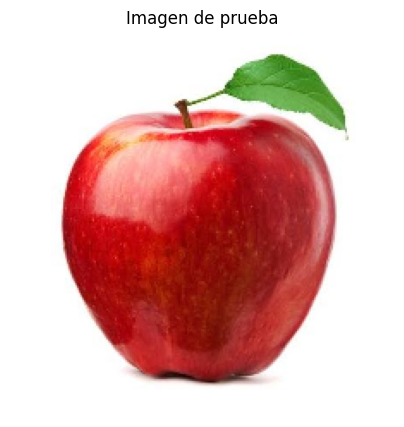

In [14]:
# Ahora se hace la prueba con una imagen de una sola fruta
img_path = "apple.jpg"

img = image.load_img(img_path, target_size=(224,224))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

In [11]:
x = image.img_to_array(img)

x = np.expand_dims(x, axis=0)

x = preprocess_input(x)

In [12]:
# predicción del modelo
pred = model.predict(x)

resultado = decode_predictions(pred, top=5)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


In [13]:
print("Top 5 predicciones:\n")

for i, (_, clase, prob) in enumerate(resultado, start=1):
    print(f"{i}. {clase:20s} {prob*100:.2f}%")

Top 5 predicciones:

1. pomegranate          54.07%
2. bell_pepper          9.32%
3. strawberry           8.38%
4. Granny_Smith         8.00%
5. buckeye              2.45%


In [ ]:
'''
En este último caso, con una sola imagen que no cause tanto ruido le es mas fácil al modelo entrenado
tratar de identificar un solo tipo, por así decirlo de qué manzana es
'''